# Notes 14

Numerical Methods for Differential Equations

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from IPython.display import display, Math, Image
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['axes.spines.top']   = False
mpl.rcParams['axes.spines.right'] = False

## Goals

In this section, we will:

1.  Understand why **numerical methods** are indispensable — most
    differential equations arising in science and engineering cannot be
    solved analytically, and even those that can are often more usefully
    studied numerically.

2.  Derive the **Euler method** (6.5) from a first-order Taylor
    expansion and interpret it geometrically as “stepping along the
    slope field.”

3.  Understand the **local truncation error** $O(h^2)$ and the **global
    (cumulative) error** $O(h)$ for the Euler method, and verify the
    $O(h)$ convergence rate numerically.

4.  Derive the **modified Euler method** (predictor–corrector,
    second-order Runge–Kutta) and understand why its global error is
    $O(h^2)$.

5.  State the **fourth-order Runge–Kutta (RK4)** update formula and its
    four slope evaluations $k_1, k_2, k_3, k_4$, giving a global error
    $O(h^4)$.

6.  Extend all three methods to **systems of ODEs** (§6.3), writing out
    the Euler, modified Euler, and RK4 update formulas for the
    two-dimensional system $x' = f(t,x,y)$, $y' = g(t,x,y)$.

7.  Use **`scipy.integrate.solve_ivp`** as a practical tool for solving
    IVPs, selecting solvers, controlling tolerances, and interpreting
    results.

> **Note**
>
> This material corresponds to **Sections 6.2 and 6.3** of Logan (2015).

------------------------------------------------------------------------

## Why Numerical Methods?

Most differential equations cannot be solved analytically by a simple
formula. In industry and science, differential equations are almost
always solved numerically because most real-world models lead to models
too complicated to solve analytically. And, in the rare case that the
problem can be solved analytically, the solution is often in the form of
a complicated integral or infinite series which must be resolved by a
computer calculation anyway. Logan remarks that “many would say that the
material in this brief section is the most important in the entire
book.”

The goal is this: given the IVP

$$x' = f(t, x), \qquad x(t_0) = x_0, \tag{6.3}$$

produce a sequence of approximations $X_0, X_1, X_2, \ldots, X_N$ at
discrete times $t_0 < t_1 < \cdots < t_N = T$, connected by straight
line segments, that accurately represents the true solution $x(t)$.

------------------------------------------------------------------------

## Section 6.2 — Numerical Methods

### Discretization

We divide the interval $[t_0, T]$ into $N$ equal subintervals of length

$$h = \frac{T - t_0}{N} \qquad (\text{the \textbf{step size}}),$$

defining the equally-spaced grid

$$t_n = t_0 + nh, \quad n = 0, 1, 2, \ldots, N.$$

We seek a **recursive formula** that computes $X_{n+1}$ from $X_n$.
Starting from $X_0 = x_0$, this formula is applied $N$ times to march
from $t_0$ to $T$, yielding the **numerical solution** $\{(t_n, X_n)\}$.

------------------------------------------------------------------------

### Section 6.2.1 — The Euler Method

#### Derivation

Integrate the ODE $x'(t) = f(t, x(t))$ from $t_n$ to $t_{n+1}$:

$$\int_{t_n}^{t_{n+1}} x'(t)\,dt = \int_{t_n}^{t_{n+1}} f(t, x(t))\,dt. \tag{6.4}$$

The left side equals $x(t_{n+1}) - x(t_n)$ by the Fundamental Theorem.
The right side is approximated by the **left-hand (rectangle) rule**:
replace $f(t, x(t))$ by its value at the left endpoint $t_n$:

$$x(t_{n+1}) - x(t_n) = h\,f(t_n, x(t_n)) + O(h^2).$$

Neglecting the $O(h^2)$ term and writing $X_n$ for the approximation of
$x(t_n)$:

> **The Euler Method**
>
> $$X_{n+1} = X_n + h\,f(t_n, X_n), \quad n = 0, 1, 2, \ldots, N, \tag{6.5}$$
> with $X_0 = x_0$.

#### Geometric Interpretation

At each step, the Euler method draws the **tangent line** to the
solution curve at $(t_n, X_n)$, which lies in the direction of the slope
field, and follows it for a distance $h$ to obtain $X_{n+1}$. It is an
**explicit** method — $X_{n+1}$ is computed directly from $X_n$ with no
equation to solve.

#### Error Analysis

- **Local truncation error:** $O(h^2)$ per step (error introduced in
  approximating one integral).
- **Global (cumulative) error:** $O(h)$ over the whole interval (since
  there are $N = (T-t_0)/h$ steps, $N \cdot O(h^2) = O(h)$). Euler’s
  method is said to be **first-order accurate**.
- **Consequence:** halving $h$ approximately halves the global error.

------------------------------------------------------------------------

### Visualizing the Euler Method

The animation below shows the Euler method applied to $x' = t - x$,
$x(0) = 1$ with $h = 0.25$. At each step: the green segment shows the
Euler step (following the local slope); the orange bracket shows the
local error (gap between the approximate and exact values).

<figure>
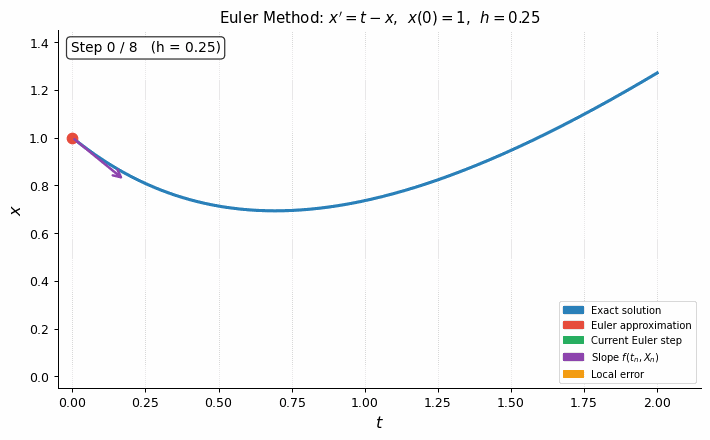
<figcaption aria-hidden="true">Euler method animation: <span
class="math inline"><em>x</em><sup>′</sup> = <em>t</em> − <em>x</em></span>,
<span class="math inline"><em>x</em>(0) = 1</span>, <span
class="math inline"><em>h</em> = 0.25</span>. The green segment at each
step follows the slope field; the orange bracket shows the growing gap
between the numerical approximation (red) and the exact solution
(blue).</figcaption>
</figure>

------------------------------------------------------------------------

### Example 6.3 — Euler Method by Hand

**Solve** $x' = t - x$, $x(0) = 1$ on $[0, 2]$ with $N = 8$ steps
($h = 0.25$). Here $f(t,x) = t - x$ and $t_n = 0.25n$. The Euler
recurrence is

$$X_{n+1} = X_n + 0.25(t_n - X_n) = X_n + 0.25(0.25n - X_n).$$

Starting with $X_0 = 1$:

$$X_1 = 1 + 0.25(0 - 1) = 0.75, \quad X_2 = 0.75 + 0.25(0.25 - 0.75) = 0.625.$$

Continuing: $X_3 = 0.594$, $X_4 = 0.632$, $\ldots$, $X_7 = 1.017$,
$X_8 = 1.200$.

The exact solution (by integrating factor) is $x(t) = t - 1 + 2e^{-t}$,
giving $x(2) = 1.2707$.

In [2]:
def f_ex(t, x):
    return t - x

def euler(f, t0, T, x0, N):
    h = (T - t0) / N
    t = np.linspace(t0, T, N+1)
    X = np.zeros(N+1); X[0] = x0
    for n in range(N):
        X[n+1] = X[n] + h * f(t[n], X[n])
    return t, X

def exact_ex(t):
    return t - 1 + 2*np.exp(-t)

t0, T, x0 = 0.0, 2.0, 1.0
t_fine = np.linspace(t0, T, 400)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t_fine, exact_ex(t_fine), 'steelblue', lw=2.8, label='Exact $x(t)=t-1+2e^{-t}$')

colors = ['crimson', 'darkorange', 'seagreen']
Nvals  = [4, 8, 16]
hvals  = [(T-t0)/N for N in Nvals]

for N, color, h in zip(Nvals, colors, hvals):
    t_e, X_e = euler(f_ex, t0, T, x0, N)
    err = abs(exact_ex(T) - X_e[-1])
    ax.plot(t_e, X_e, color=color, lw=1.8, marker='o', markersize=5,
            label=f'Euler $h={h}$, error at $t=2$: {err:.4f}')

ax.set_xlabel('$t$'); ax.set_ylabel('$x$')
ax.set_title("Example 6.3: Euler method convergence")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Error table
print(f"{'h':>8}  {'X(2)':>8}  {'error':>8}")
print("-" * 28)
for N, h in zip(Nvals, hvals):
    _, X_e = euler(f_ex, t0, T, x0, N)
    err = exact_ex(T) - X_e[-1]
    print(f"{h:8.4f}  {X_e[-1]:8.4f}  {err:8.4f}")
print(f"{'exact':>8}  {exact_ex(T):8.4f}  {'0':>8}")

       h      X(2)     error
----------------------------
  0.5000    1.1250    0.1457
  0.2500    1.2002    0.0704
  0.1250    1.2361    0.0345
   exact    1.2707         0

------------------------------------------------------------------------

### The Modified Euler Method (Second-Order Runge–Kutta)

To improve accuracy, replace the left-hand rectangle rule in (6.4) with
the **trapezoidal rule**:

$$x(t_{n+1}) - x(t_n) = \frac{h}{2}\bigl[f(t_n, x(t_n)) + f(t_{n+1}, x(t_{n+1}))\bigr] + O(h^3).$$

This gives a **local truncation error** of $O(h^3)$ and a **global
error** of $O(h^2)$. The formula (6.6) involves $X_{n+1}$ on both sides
(an **implicit** equation), making it expensive to solve at each step.

The practical fix is a **predictor–corrector** approach:

> **Modified Euler Method (RK2)**
>
> **Predictor** (Euler step):
> $$\widetilde{X}_{n+1} = X_n + h\,f(t_n, X_n). \tag{6.7}$$
>
> **Corrector** (trapezoidal average):
> $$X_{n+1} = X_n + \frac{h}{2}\bigl[f(t_n, X_n) + f(t_{n+1}, \widetilde{X}_{n+1})\bigr]. \tag{6.8}$$
>
> Global error: $O(h^2)$. Also called the **second-order Runge–Kutta
> method**.

The new value $X_{n+1}$ is the average of the slope at the current point
and the (predicted) slope at the next point.

------------------------------------------------------------------------

### Section 6.2.2 — The Fourth-Order Runge–Kutta Method (RK4)

The most widely used algorithm for numerical ODEs is the **classical
fourth-order Runge–Kutta method**, which achieves a global error of
$O(h^4)$. It evaluates $f$ at four carefully chosen points within each
interval:

> **The Runge–Kutta Method (RK4)**
>
> $$X_{n+1} = X_n + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4),$$
> where
> $$k_1 = f(t_n,\; X_n), \quad
> k_2 = f\!\left(t_n + \tfrac{h}{2},\; X_n + \tfrac{h}{2}k_1\right),$$
>
> $$k_3 = f\!\left(t_n + \tfrac{h}{2},\; X_n + \tfrac{h}{2}k_2\right), \quad
> k_4 = f(t_n + h,\; X_n + h\,k_3).$$
> The new value is a **weighted average** of four slopes
> $k_1, \ldots, k_4$ sampled at the left endpoint, two midpoints, and
> the right endpoint.

#### Error Comparison

For $h = 0.1$, the cumulative errors for the three methods are
proportional to:

| Method               | Order    | Error ($h=0.1$) |
|----------------------|----------|-----------------|
| Euler                | $O(h)$   | $\sim 0.1$      |
| Modified Euler (RK2) | $O(h^2)$ | $\sim 0.01$     |
| Runge–Kutta (RK4)    | $O(h^4)$ | $\sim 0.0001$   |

In [3]:
def modified_euler(f, t0, T, x0, N):
    h = (T - t0) / N
    t = np.linspace(t0, T, N+1)
    X = np.zeros(N+1); X[0] = x0
    for n in range(N):
        Xt = X[n] + h * f(t[n], X[n])
        X[n+1] = X[n] + (h/2) * (f(t[n], X[n]) + f(t[n+1], Xt))
    return t, X

def rk4(f, t0, T, x0, N):
    h = (T - t0) / N
    t = np.linspace(t0, T, N+1)
    X = np.zeros(N+1); X[0] = x0
    for n in range(N):
        k1 = f(t[n],       X[n])
        k2 = f(t[n]+h/2,   X[n]+h/2*k1)
        k3 = f(t[n]+h/2,   X[n]+h/2*k2)
        k4 = f(t[n]+h,     X[n]+h*k3)
        X[n+1] = X[n] + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
    return t, X

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: solution comparison with h=0.5
N_demo = 4
t_fine = np.linspace(0, 2, 400)
axes[0].plot(t_fine, exact_ex(t_fine), 'steelblue', lw=2.8,
             label='Exact')
for method, color, lbl in [
        (euler,          'crimson',    'Euler (RK1)'),
        (modified_euler, 'darkorange', 'Modified Euler (RK2)'),
        (rk4,            'seagreen',   'Runge–Kutta (RK4)')]:
    t_m, X_m = method(f_ex, 0, 2, 1, N_demo)
    axes[0].plot(t_m, X_m, marker='o', markersize=6, lw=2.0,
                 color=color, label=lbl)
axes[0].set_xlabel('$t$'); axes[0].set_ylabel('$x$')
axes[0].set_title('Solution comparison ($h=0.5$)')
axes[0].legend(fontsize=9)

# Right: convergence log-log
h_vals = [0.5, 0.25, 0.125, 0.0625, 0.03125]
for method, color, lbl, order in [
        (euler,          'crimson',    'Euler $O(h)$',    1),
        (modified_euler, 'darkorange', 'RK2 $O(h^2)$',   2),
        (rk4,            'seagreen',   'RK4 $O(h^4)$',   4)]:
    errs = []
    for h in h_vals:
        N_ = int(2/h)
        _, X_m = method(f_ex, 0, 2, 1, N_)
        errs.append(abs(exact_ex(2) - X_m[-1]))
    axes[1].loglog(h_vals, errs, marker='o', color=color, lw=2.0, label=lbl)
    # Reference slope
    h_arr = np.array(h_vals)
    axes[1].loglog(h_arr, errs[0]*(h_arr/h_vals[0])**order,
                   ls='--', color=color, lw=1.0, alpha=0.6)

axes[1].set_xlabel('Step size $h$'); axes[1].set_ylabel('Global error at $t=2$')
axes[1].set_title('Convergence (log–log)')
axes[1].legend(fontsize=9)
axes[1].grid(True, which='both', alpha=0.3)

plt.suptitle(r"Method comparison: $x'=t-x$, $x(0)=1$", fontsize=12)
plt.tight_layout()
plt.show()

------------------------------------------------------------------------

### Error Sources

There are three sources of error in a finite difference scheme:

1.  **Truncation error** — arises from approximating the continuous
    problem by a discrete one (Taylor series truncation). This is the
    $O(h^p)$ error analyzed above.

2.  **Stability error** — the discrete algorithm itself may be unstable:
    an error at an early step can be amplified as it propagates forward
    in time. The step size $h$ must be kept below a problem-dependent
    threshold.

3.  **Roundoff error** — a computer represents real numbers with finite
    precision. The actual computed value $\overline{X}_n$ differs from
    the mathematically exact discrete value $X_n$ by the roundoff error
    $X_n - \overline{X}_n$.

The total error at $t_n$ is

$$x(t_n) - \overline{X}_n = \underbrace{(x(t_n) - X_n)}_{\text{truncation}} + \underbrace{(X_n - \overline{X}_n)}_{\text{roundoff}}.$$

> **Stiff Equations**
>
> Some differential equations are **stiff**: they have components that
> change at vastly different time scales. Simple slope-following methods
> like Euler and even RK4 require extremely small step sizes to remain
> stable on stiff problems. **Stiff solvers** (e.g., backward Euler,
> implicit Runge–Kutta) are required; `scipy` provides these via the
> `method='Radau'` or `method='BDF'` options in `solve_ivp`.

------------------------------------------------------------------------

## Section 6.3 — Numerical Methods for Systems

The single-equation methods extend immediately to the two-dimensional
system

$$x' = f(t, x, y), \qquad y' = g(t, x, y),$$

with initial conditions $x(t_0) = x_0$, $y(t_0) = y_0$. We write
$X_n \approx x(t_n)$ and $Y_n \approx y(t_n)$.

### Euler Method for Systems

$$X_{n+1} = X_n + h\,f(t_n, X_n, Y_n),$$

$$Y_{n+1} = Y_n + h\,g(t_n, X_n, Y_n).$$

### Modified Euler Method for Systems

**Predictors:**
$$\widetilde{X}_{n+1} = X_n + h\,f(t_n, X_n, Y_n), \qquad \widetilde{Y}_{n+1} = Y_n + h\,g(t_n, X_n, Y_n).$$

**Correctors:**
$$X_{n+1} = X_n + \frac{h}{2}\bigl[f(t_n, X_n, Y_n) + f(t_{n+1}, \widetilde{X}_{n+1}, \widetilde{Y}_{n+1})\bigr],$$
$$Y_{n+1} = Y_n + \frac{h}{2}\bigl[g(t_n, X_n, Y_n) + g(t_{n+1}, \widetilde{X}_{n+1}, \widetilde{Y}_{n+1})\bigr].$$

### Runge–Kutta Method for Systems

Compute eight slopes at each step:

$$k_{11} = f(t_n, X_n, Y_n), \quad k_{21} = g(t_n, X_n, Y_n),$$

$$k_{12} = f\!\left(t_n+\tfrac{h}{2},\; X_n+\tfrac{h}{2}k_{11},\; Y_n+\tfrac{h}{2}k_{21}\right), \quad
k_{22} = g\!\left(t_n+\tfrac{h}{2},\; X_n+\tfrac{h}{2}k_{11},\; Y_n+\tfrac{h}{2}k_{21}\right),$$

$$k_{13} = f\!\left(t_n+\tfrac{h}{2},\; X_n+\tfrac{h}{2}k_{12},\; Y_n+\tfrac{h}{2}k_{22}\right), \quad
k_{23} = g\!\left(t_n+\tfrac{h}{2},\; X_n+\tfrac{h}{2}k_{12},\; Y_n+\tfrac{h}{2}k_{22}\right),$$

$$k_{14} = f(t_n+h,\; X_n+hk_{13},\; Y_n+hk_{23}), \quad
k_{24} = g(t_n+h,\; X_n+hk_{13},\; Y_n+hk_{23}).$$

Then:

$$X_{n+1} = X_n + \frac{h}{6}(k_{11} + 2k_{12} + 2k_{13} + k_{14}),$$

$$Y_{n+1} = Y_n + \frac{h}{6}(k_{21} + 2k_{22} + 2k_{23} + k_{24}).$$

The global errors remain order $h$, $h^2$, and $h^4$ for Euler, modified
Euler, and RK4, respectively. The procedure extends in the same way to
systems of any dimension.

------------------------------------------------------------------------

## Using `scipy.integrate.solve_ivp`

### Why Use `solve_ivp`?

Rather than programming the methods above from scratch (which is
valuable for understanding), in practice we use
`scipy.integrate.solve_ivp`, which:

- Implements high-quality, **adaptive step-size** methods that
  automatically tighten $h$ where the solution changes rapidly and relax
  it where it is smooth.
- Provides multiple solvers: `'RK45'` (default, explicit 4th/5th-order),
  `'RK23'`, `'DOP853'`, `'Radau'` (stiff), `'BDF'` (stiff), `'LSODA'`.
- Returns a rich result object with solution values, time points,
  success/failure status, and optionally a dense interpolant.

### Basic Usage

In [4]:
from scipy.integrate import solve_ivp

# Define the right-hand side: must accept (t, y) where y is a 1-D array
def rhs(t, y):
    return [t - y[0]]       # y[0] is x(t)

# Solve
sol = solve_ivp(
    fun     = rhs,          # right-hand side f(t, y)
    t_span  = (0, 2),       # integration interval [t0, T]
    y0      = [1.0],        # initial condition (list or array)
    method  = 'RK45',       # solver (default; adaptive 4th/5th-order RK)
    dense_output = True,    # enable continuous interpolant sol.sol(t)
    rtol    = 1e-6,         # relative tolerance
    atol    = 1e-8,         # absolute tolerance
)

print(f"Success: {sol.success}")
print(f"Solver steps taken: {len(sol.t)}")
print(f"x(2) ≈ {sol.y[0, -1]:.8f}  (exact: {exact_ex(2):.8f})")

# Plot using the dense interpolant
t_plot = np.linspace(0, 2, 400)
x_interp = sol.sol(t_plot)[0]   # shape (1, 400) → take row 0

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_plot, exact_ex(t_plot), 'steelblue', lw=2.5, label='Exact')
ax.plot(t_plot, x_interp, 'seagreen', lw=2.0, ls='--', label='solve_ivp RK45')
ax.plot(sol.t, sol.y[0], 'go', markersize=5,
        label=f'Adaptive steps (N={len(sol.t)})')
ax.set_xlabel('$t$'); ax.set_ylabel('$x(t)$')
ax.set_title(r"$x'=t-x$, $x(0)=1$ via `solve_ivp`")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Success: True
Solver steps taken: 11
x(2) ≈ 1.27067069  (exact: 1.27067057)

### Solving Systems with `solve_ivp`

For a system, simply stack the state variables into a vector and define
the right-hand side accordingly:

In [5]:
# Lotka-Volterra: x' = ax - bxy,  y' = -cy + dxy
a, b, c, d = 0.6, 0.5, 0.3, 0.4

def lv_rhs(t, z):
    x, y = z
    return [a*x - b*x*y,
            -c*y + d*x*y]

sol_lv = solve_ivp(
    fun          = lv_rhs,
    t_span       = (0, 60),
    y0           = [c/d + 0.4, a/b],   # perturbed from equilibrium
    method       = 'RK45',
    dense_output = True,
    rtol         = 1e-9,
    atol         = 1e-11,
    max_step     = 0.05,
)

t_p = np.linspace(0, 60, 1500)
z_p = sol_lv.sol(t_p)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(t_p, z_p[0], 'steelblue', lw=2.5, label='$x(t)$ prey')
axes[0].plot(t_p, z_p[1], 'crimson',   lw=2.5, label='$y(t)$ predator')
axes[0].axhline(c/d, color='steelblue', ls=':', lw=1, alpha=0.7)
axes[0].axhline(a/b, color='crimson',   ls=':', lw=1, alpha=0.7)
axes[0].set_xlabel('$t$'); axes[0].set_ylabel('Population')
axes[0].set_title('Lotka–Volterra time series')
axes[0].legend(fontsize=9)

axes[1].plot(z_p[0], z_p[1], 'seagreen', lw=1.8)
axes[1].plot(c/d, a/b, 'o', color='steelblue', markersize=9,
             label=f'Equilibrium $({c/d:.2f},{a/b:.2f})$')
axes[1].set_xlabel('$x$ (prey)'); axes[1].set_ylabel('$y$ (predator)')
axes[1].set_title('Phase portrait')
axes[1].legend(fontsize=9)

plt.suptitle(f'Lotka–Volterra ($a={a}$, $b={b}$, $c={c}$, $d={d}$)', fontsize=11)
plt.tight_layout()
plt.show()

### Key `solve_ivp` Options

| Option | Purpose | Typical value |
|------------------------|------------------------|------------------------|
| `method` | Solver algorithm | `'RK45'` (default), `'Radau'` (stiff) |
| `t_eval` | Times at which to store solution | `np.linspace(t0, T, 500)` |
| `dense_output` | Enable `sol.sol(t)` interpolant | `True` |
| `rtol` | Relative tolerance | `1e-6` (default `1e-3`) |
| `atol` | Absolute tolerance | `1e-8` (default `1e-6`) |
| `max_step` | Upper bound on step size | Useful for periodic problems |
| `events` | Detect zero-crossings | Function returning scalar |

> **Choosing a Solver**
>
> - **Non-stiff problems** (most problems in this course): `'RK45'`
>   (default) is excellent.
> - **Stiff problems** (large Jacobian eigenvalue spread): use `'Radau'`
>   or `'BDF'`.
> - **High accuracy needed**: `'DOP853'` (8th-order explicit).
> - **When in doubt**: try `'RK45'` first. If it is slow or fails to
>   converge, switch to `'Radau'`.

------------------------------------------------------------------------

## Summary

| Method | Formula | Global error | Evaluations/step |
|------------------|------------------|------------------|------------------|
| **Euler** | $X_{n+1}=X_n+hf(t_n,X_n)$ | $O(h)$ | 1 |
| **Modified Euler (RK2)** | Predictor (6.7) + Corrector (6.8) | $O(h^2)$ | 2 |
| **Runge–Kutta (RK4)** | Weighted avg of $k_1,k_2,k_3,k_4$ | $O(h^4)$ | 4 |
| **`solve_ivp` RK45** | Adaptive embedded pair | $O(h^5)$, auto-$h$ | varies |

All three methods extend to systems by treating $(X_n, Y_n)$ as a vector
and applying the scalar formula component-wise. The global error orders
$O(h)$, $O(h^2)$, $O(h^4)$ are unchanged.

> **Looking Ahead**
>
> The methods in this section — particularly RK4 and `solve_ivp` — are
> the tools used throughout numerical science and engineering. They
> underlie every phase portrait produced in Chapters 4 and 5 of Logan,
> all the nonlinear systems analyzed in Chapter 5, and the time-series
> solutions for models in biology, chemistry, and physics. Understanding
> *why* these methods work, not just *how* to call them, is the lasting
> take-away from this chapter.

------------------------------------------------------------------------

These notes are also viewable as a slide deck presentation:
<a href="https://math341diffeq.netlify.app/notes_14_slides.html"
target="_blank">Open slides in full screen</a>

> **Note**
>
> **Next:** Review and additional computational topics.

------------------------------------------------------------------------

## Relevant Videos

### Numerical Methods for ODEs — Overview:

### The Euler Method:

### Runge–Kutta Methods:

### The Euler Method for Systems:

### `scipy.integrate.solve_ivp` Tutorial:

## References

Logan, J David. 2015. *A First Course in Differential Equations, Third
Edition*.

> **Expand for Session Info**
>
> ``` python
> import sys
> print("Python version:", sys.version)
> print('\n'.join(f'{m.__name__}=={m.__version__}' for m in globals().values() if getattr(m, '__version__', None)))
> ```
>
>     Python version: 3.14.4 | packaged by conda-forge | (main, Apr  8 2026, 02:33:53) [Clang 20.1.8 ]
>     numpy==2.4.3
>     matplotlib==3.10.8

[![](http://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc-sa.png?raw=1)](https://creativecommons.org/licenses/by-nc-sa/4.0/legalcode)